In [9]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Features (X) and target (y)
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

# One-Hot Encode 'region' (avoid dummy variable trap)
X = pd.get_dummies(
    X,
    columns=["region"],
    drop_first=True,
    dtype=int
)

# Binary encoding for categorical features
X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

In [5]:
# Split data into training and testing sets
# 75% train, 25% test | random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [12]:
lasso_model   = Lasso(alpha = 0.5)
lasso_model.fit(X_train , y_train)

y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print("MSE :- " , mse)
mse.append(mse)

MSE :-  35119349.80312223


MSE for alpha = 0.001:-  35119349.80312223
MSE for alpha = 0.1:-  35119349.80312223
MSE for alpha = 0.2:-  35119349.80312223
MSE for alpha = 0.5:-  35119349.80312223
MSE for alpha = 0.9:-  35119349.80312223
MSE for alpha = 1:-  35119349.80312223
MSE for alpha = 2:-  35119349.80312223
MSE for alpha = 5:-  35119349.80312223
MSE for alpha = 10:-  35119349.80312223
MSE for alpha = 16:-  35119349.80312223
MSE for alpha = 30:-  35119349.80312223
MSE for alpha = 50:-  35119349.80312223


<Axes: >

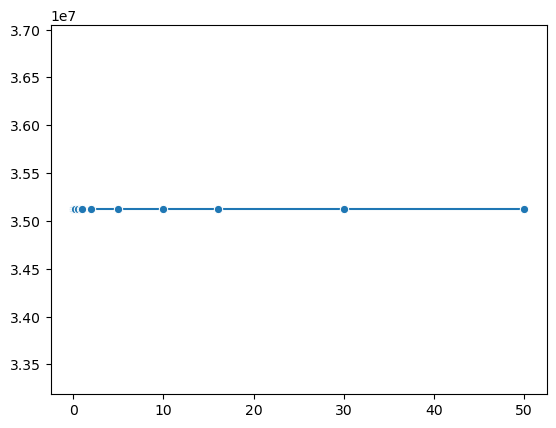

In [19]:
import seaborn as sns
alpha = [0.001 , 0.1 , 0.2 ,0.5, 0.9,  1, 2, 5, 10 ,16, 30, 50]
mses =[]
for  a in alpha : 
    lasso_model   = Lasso(alpha = 0.5)
    lasso_model.fit(X_train , y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    print(f"MSE for alpha = {a}:- " , mse)

sns.lineplot(x=alpha , y = mse , marker = "o")